# Example notebook of a Sample QC analysis

The present notebook serves as a guide of how use the `IDEAL-GENOM-QC` library to perform a sample quality control. We intend to show a possible use, because each user can adapt it to its particular needs.

In this notebook the procedure to perform the sample quality control is more detailed so the user can get a deeper understanding of all the steps executed in this part of the pipeline.

Let us import the required libraries.

In [1]:
import sys
import os

import pandas as pd

from pathlib import Path

# add parent directory to path
library_path = os.path.abspath('..')
if library_path not in sys.path:
    sys.path.append(library_path)

library_path = Path(library_path)

from ideal_genom.qc.sample_qc import SampleQC, SampleQCReport, SampleQCCleanUp

In the next cell the path variables associated with the project are set.

Moreover, since each user can have a slightly different choices for the LD regions, the user can provide its own file. Nevertheless, we provide the functionality of automatically fetching high LD regions for builts **GRCh37** and **GRCH38**.

Let us set the path parameters to execute the sample QC.

In [2]:
DATA_PATH = library_path / 'ideal_genom' / 'data'

example_data = DATA_PATH / 'example_data'
inputData    = example_data / 'inputData'
ouputData    = example_data / 'outputData'
config       = example_data / 'config'

In [3]:
input_path = inputData
input_name = 'SAS_example'
output_path=  ouputData
output_name= '1KG_GRCh38_sample_qc'
high_ld_file = Path('path/to/ld-regions/file') # if not available, set to None

In the next cell we define a dictionary containing the parameters to execute the sample QC pipeline.

The explanation of the parameters is the following:

1. `rename_snp`: if `True` the pipeline will change the SNPs identifiers to the format chr_pos_a1_a2.
2. `hh_to_missing`: if `True` the pipeline sets heterozygous haploid to missing, check **PLINK1.9** command `--set-hh-missing` for more details.
3. `use_kinship`: if `True` the pipeline will use the KING estimator for duplicates and relatedness check; if `False`, IBD (`--genome`) is used instead.
4. `ind_pair`: parameters of **PLINK1.9** `--indep-pairwise`.
5. `mind`: call rate threshold (F_MISS) above which a sample fails.
6. `sex_check`: parameters of **PLINK1.9** `--sex-check`.
7. `maf`: minor allele frequency, parameter of **PLINK1.9** `--maf`.
8. `het_deviation`: number of standard deviations from the mean heterozygosity rate used to flag outliers.
9. `kinship`: kinship coefficient threshold, parameter of **PLINK2** `--king-cutoff`.
10. `ibd_threshold`: PI_HAT threshold to filter samples according to IBD (only used if `use_kinship=False`).

In [4]:
sample_params = {
    "rename_snp"   : True,
    "hh_to_missing": True,
    "use_kinship" : True,
    "ind_pair"     : [20000, 2000, 0.5],
    "mind"         : 0.00025,
    "sex_check"    : [0.5, 0.8],
    "maf"          : 0.05,
    "het_deviation": 2,
    "kinship"     : 0.354,
    "ibd_threshold": 0.185
}

Initialize the class `SampleQC`.

In [5]:
sample_qc = SampleQC(
    input_path      =input_path,
    input_name      =input_name,
    output_path     =output_path,
    output_name     =output_name,
    high_ld_regions_file    =high_ld_file,
    build           ='38', # '38' it is the default value
)

INFO:ideal_genom.qc.sample_qc:High LD file not found at path/to/ld-regions/file
INFO:ideal_genom.qc.sample_qc:High LD file will be fetched from the package
INFO:ideal_genom.qc.sample_qc:High LD file fetched from the package and saved at /home/luis/CGE/ideal-genom-qc/ideal_genom/data/ld_regions_files/high-LD-regions_GRCH38.txt


Execute the pipeline steps of the sample quality control. `execute_sample_qc_pipeline()` runs every QC step in order, aggregates the failing samples, and drops them, producing cleaned `PLINK` files in `sample_qc.clean_dir`.

The pipeline shells out to PLINK many times, which prints a lot of console text; we capture it into `sample_qc_log` to keep the notebook readable — run `sample_qc_log.show()` in a new cell if you need to inspect it.

In [6]:
log_path = "logs/sample_qc.log"

with open(log_path, "w") as f:
    old_stdout_fd = os.dup(1)
    old_stderr_fd = os.dup(2)
    
    try:
        os.dup2(f.fileno(), 1)
        os.dup2(f.fileno(), 2)
        
        sample_qc.execute_sample_qc_pipeline(sample_params=sample_params)
    finally:
        os.dup2(old_stdout_fd, 1)
        os.dup2(old_stderr_fd, 2)
        os.close(old_stdout_fd)
        os.close(old_stderr_fd)

print(f"Pipeline complete. Log saved to: {log_path}")

INFO:ideal_genom.qc.sample_qc:Starting Sample Quality Control Pipeline
INFO:ideal_genom.qc.sample_qc:STEP: Rename SNPs. `rename` set to True. Renaming SNPs in the study data to the format chr_pos_a1_a2
INFO:ideal_genom.qc.sample_qc:STEP: Convert haploid genotypes to missing values. `hh_to_missing` set to True. Converting haploid genotypes to missing values in the study data
INFO:ideal_genom.core.executor:Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example --set-all-var-ids @:#:$r:$a --set-invalid-haploid-missing --threads 30 --memory 33306 --make-bed --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example-processed
INFO:ideal_genom.core.executor:Command completed successfully
INFO:ideal_genom.qc.sample_qc:Successfully completed step: pre-processing


Rename SNPs to chr:pos:ref:alt and solve hh warnings by setting to missing.


INFO:ideal_genom.qc.sample_qc:Memory usage after pre-processing: 20.1%
INFO:ideal_genom.qc.sample_qc:STEP: LD pruning
INFO:ideal_genom.core.executor:Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example-processed --exclude /home/luis/CGE/ideal-genom-qc/ideal_genom/data/ld_regions_files/high-LD-regions_GRCH38.txt --memory 33324 --threads 30 --make-bed --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/SAS_example-LDregionExcluded
INFO:ideal_genom.core.executor:Command completed successfully


Perform LD pruning.


INFO:ideal_genom.core.executor:Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/SAS_example-LDregionExcluded --indep-pairwise 20000 2000 0.5 --memory 33324 --threads 30 --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/SAS_example-LDregionExcluded-prunning
INFO:ideal_genom.core.executor:Command completed successfully
INFO:ideal_genom.core.executor:Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/SAS_example-LDregionExcluded --extract /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/SAS_example-LDregionExcluded-prunning.prune.in --make-bed --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/SAS_example-LDpruned --memory 33324 --threads 30
INFO:ideal_genom.core.executor:Command completed successfully
INFO:ideal_genom.qc.sample_qc:Su

...

Get samples that failed quality control.


INFO:ideal_genom.qc.sample_qc:Memory usage after get_fail_samples: 20.1%
INFO:ideal_genom.qc.sample_qc:STEP: Drop samples that failed quality control checks
INFO:ideal_genom.qc.sample_qc:Binary file name: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example-processed
INFO:ideal_genom.core.executor:Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example-processed --remove /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/fail_samples/fail_samples.txt --make-bed --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/clean_files/1KG_GRCh38_sample_qc
INFO:ideal_genom.core.executor:Command completed successfully
INFO:ideal_genom.qc.sample_qc:Successfully completed step: drop_fail_samples


Drop samples that failed quality control.


INFO:ideal_genom.qc.sample_qc:Memory usage after drop_fail_samples: 20.0%
INFO:ideal_genom.qc.sample_qc:Sample Quality Control Pipeline completed successfully


Pipeline complete. Log saved to: logs/sample_qc.log


In [7]:
print(f"Sample QC pipeline completed. Clean PLINK files written to: {sample_qc.clean_dir}")

Sample QC pipeline completed. Clean PLINK files written to: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/clean_files


**Note:** `execute_sample_qc_pipeline()` already performs the full pipeline end-to-end, including aggregating all QC failures (`get_fail_samples()`) and removing them (`execute_drop_samples()`). The cells below are for *inspecting and customizing* the resulting reports — they do not need to repeat the failure aggregation or sample dropping.

In [8]:
report = SampleQCReport(
    output_path=sample_qc.plots_dir
)

Here a small dashboard with a report of the call rate missingness is shown. The cap on the Y-axis can be selected without re-running the whole pipeline, so it can be selected according to each user need. Moreover, the plots could help to choose the best call rate threshold according to the data.

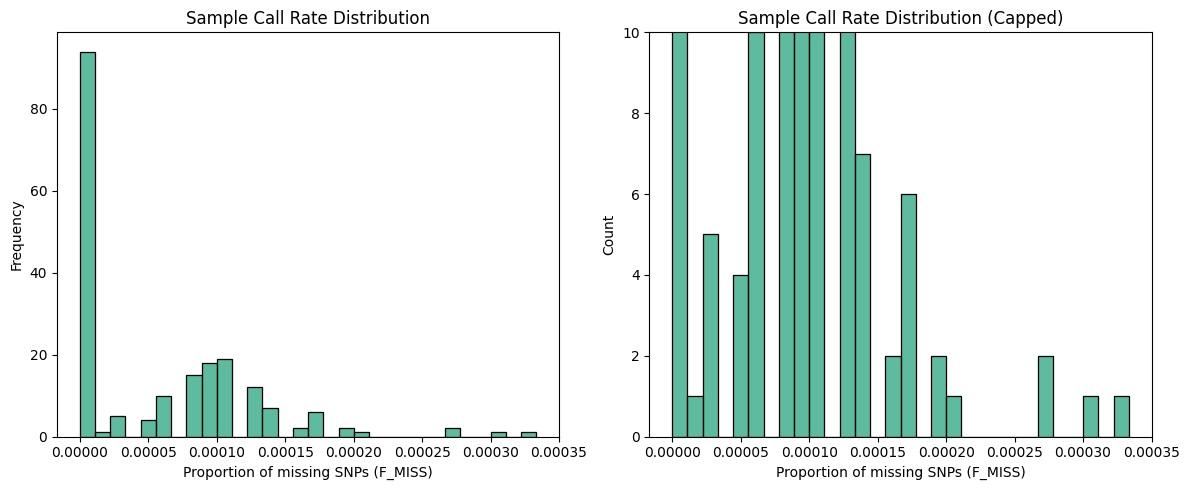

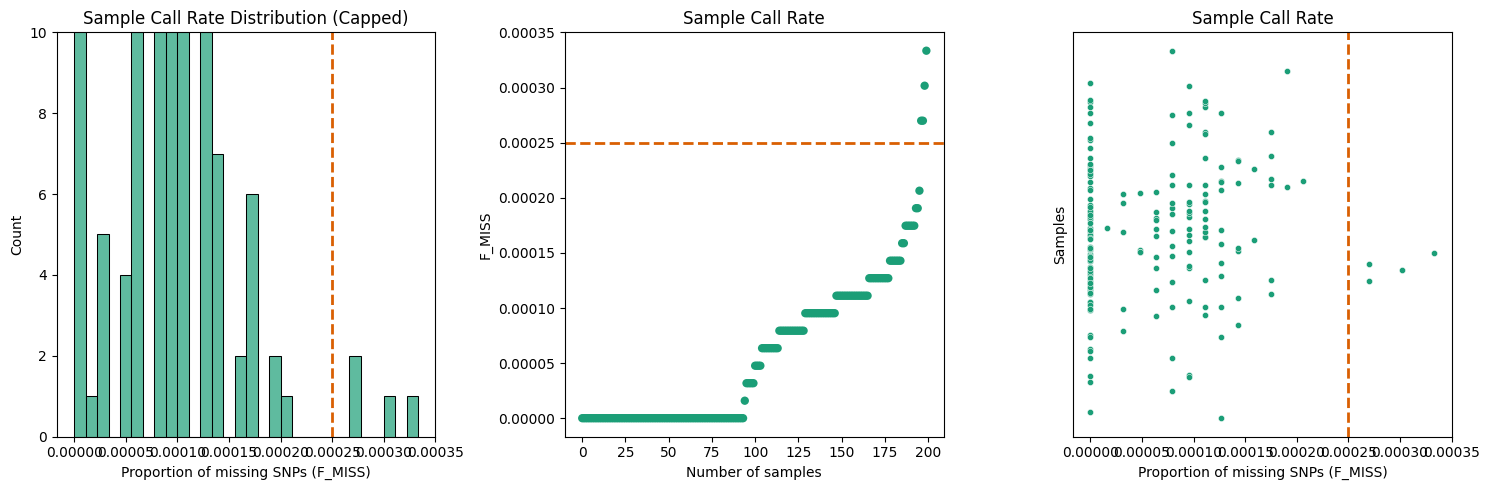

In [9]:
# Regenerate the call rate plot alone, e.g. with a different y-axis cap
report.report_call_rate(
    smiss_file=sample_qc.call_rate_miss,
    threshold=sample_params['mind'],
    plots_dir=sample_qc.plots_dir,
    y_axis_cap=10,
)

Now, a plot of the sex check results is shown, where the user can check the number of problematic samples (those with discordant sex information).

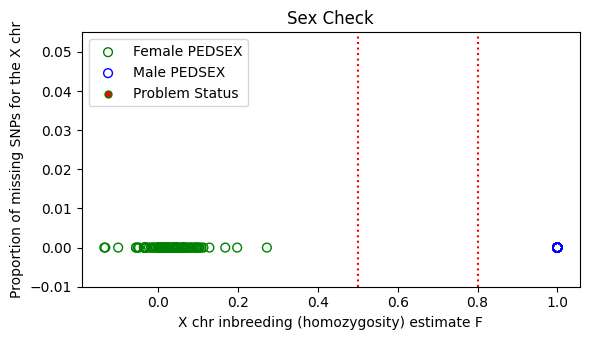

In [10]:
report.report_sex_check(
    sex_check_filename =sample_qc.sexcheck_miss,
    xchr_imiss_filename=sample_qc.xchr_miss,
    plots_dir          =sample_qc.plots_dir,
    f_coeff_thresholds =sample_params['sex_check'],
    format             ='svg',
    fig_size           =(6, 3.5)
)

Here a small dashboard with a report of the heterozigosity is shown. The cap on the Y-axis can be selected without re-running the whole pipeline, so it can be selected according to each user need. Moreover, the plots could help to choose a different deviation from the mean of the heterozigosity rate. Notice that the analysis has been divided for SNPs having a MAF of less than 1% and those above that threshold.

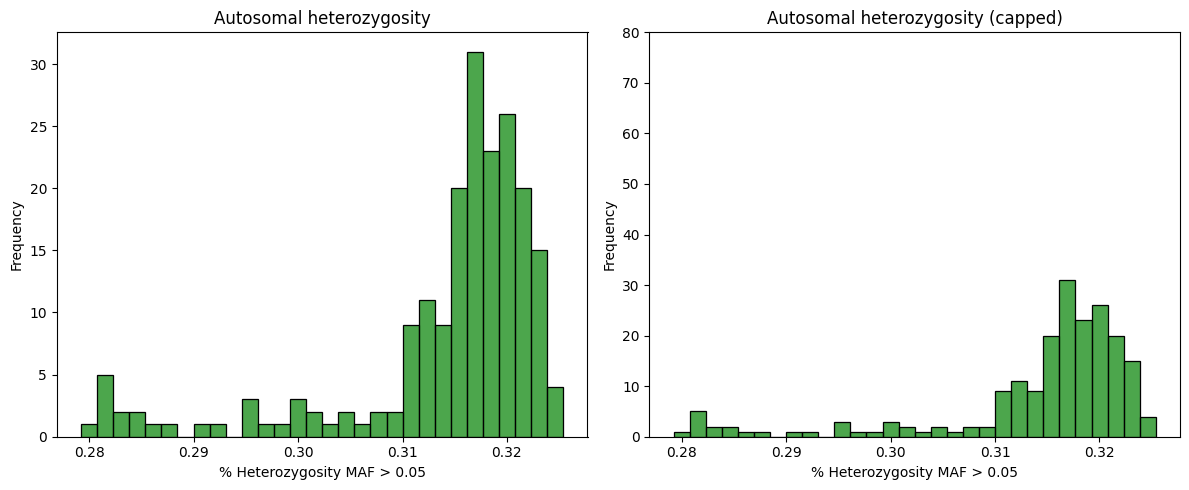

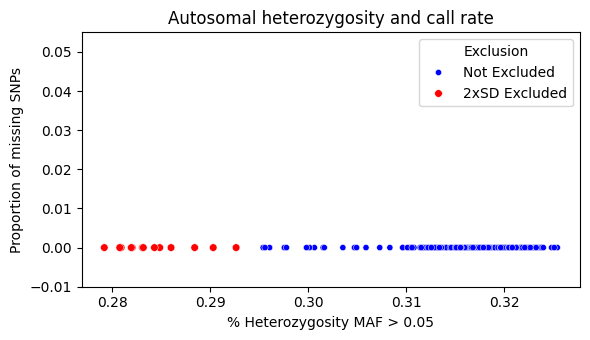

In [11]:
report.report_heterozygosity_rate(
    het_filename        = sample_qc.maf_greater_het,
    autosomal_filename  = sample_qc.maf_greater_smiss,
    std_deviation_het   = sample_params['het_deviation'],
    maf                 = sample_params['maf'],
    split               = '>',
    plots_dir           = sample_qc.plots_dir,
    format              ='svg',
    scatter_fig_size    =(6, 3.5),
)

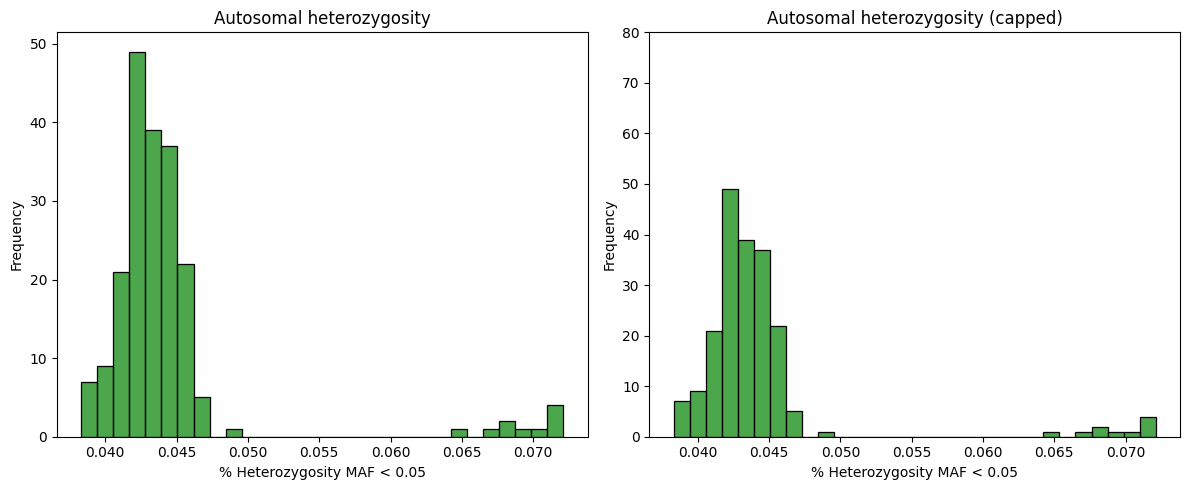

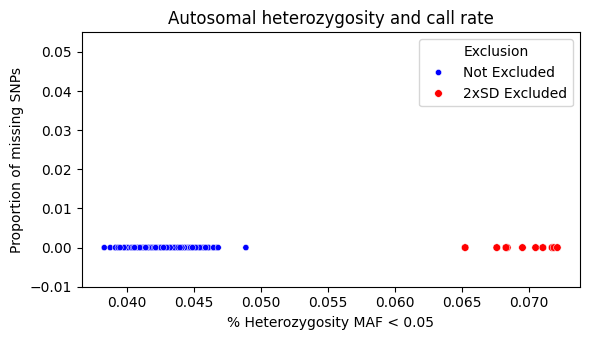

In [12]:
report.report_heterozygosity_rate(
    het_filename        = sample_qc.maf_less_het,
    autosomal_filename  = sample_qc.maf_less_smiss,
    std_deviation_het   = sample_params['het_deviation'],
    maf                 = sample_params['maf'],
    split               = '<',
    plots_dir           = sample_qc.plots_dir,
    format              ='svg',
    scatter_fig_size    =(6, 3.5),
)

Finally, let's inspect which samples were flagged as duplicates/related. The branch taken depends on `use_kinship` (KING vs. IBD).

In [13]:
if sample_qc.use_kinship:
    df_kinship_dup = pd.read_csv(
        sample_qc.kinship_miss,
        sep=r'\s+',
        engine='python',
        header=None,
        names=['FID', 'IID']
    )
    print(f"{df_kinship_dup.shape[0]} samples flagged as duplicates/related by KING")
    df_kinship_dup

1 samples flagged as duplicates/related by KING


In [14]:
if not sample_qc.use_kinship:
    report.report_ibd_analysis(
        genome       =sample_qc.genome,
        ibd_threshold=sample_params['ibd_threshold']
    )

All QC failures were already aggregated by `get_fail_samples()` inside `execute_sample_qc_pipeline()`, which wrote `fail_samples.txt` and `fail_summary.txt` to disk. Let's load them to inspect how many samples failed each check.

In [15]:
fail_summary = pd.read_csv(sample_qc.results_dir / 'fail_summary.txt', sep='\t')
fail_samples = pd.read_csv(sample_qc.fails_dir / 'fail_samples.txt', sep='\t')

In [16]:
fail_summary

,Failure,count
0,Heterozygosity rate (MAF > 0.05),14
1,Heterozygosity rate (MAF < 0.05),10
2,Call rate,4
3,Duplicated Sample IDs,-9
4,Total,19


In [17]:
print('Unique samples failing QC:', fail_samples.shape[0])

Unique samples failing QC: 19


The failing samples were already dropped by `execute_drop_samples()` inside the pipeline run above. The cleaned `PLINK` files are available at the path below.

In [18]:
clean_files = sample_qc.clean_dir / sample_qc.output_name
print(f'Clean PLINK files (samples failing QC removed): {clean_files}')

Clean PLINK files (samples failing QC removed): /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/clean_files/1KG_GRCh38_sample_qc


Some intermediate files are deleted to save space.

In [19]:
cleanup = SampleQCCleanUp(
    output_path=sample_qc.results_dir,
    input_path =sample_qc.input_path
)
cleanup.clean_all()

INFO:ideal_genom.qc.sample_qc:Cleaning up processed files from input directory
INFO:ideal_genom.qc.sample_qc:Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example-processed.bed
INFO:ideal_genom.qc.sample_qc:Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example-processed.bim
INFO:ideal_genom.qc.sample_qc:Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example-processed.fam
INFO:ideal_genom.qc.sample_qc:Cleaning up intermediate files from output directory
INFO:ideal_genom.qc.sample_qc:Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/1KG_GRCh38_sample_qc-chr1-22-mafless.bed
INFO:ideal_genom.qc.sample_qc:Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/sample_qc_results/SAS_example-LDpruned.bed
INFO:ideal_genom.qc.sample_qc:Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/s